In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import glob

In [7]:
instance_progression = {
    "50": {},
    "150": {},
    "650": {},
    "1000": {}
}
csv_files = glob.glob('simulated/*.csv')
for instance_file in csv_files:
    instance = pd.read_csv(instance_file)
    instance_info = instance_file.split(".")[0].split("-")
    instance_alg = instance_info[4]
    if instance_alg == "A":
        instance_capacity = instance_info[5]
        vams = instance_info[7]
        instance_name = f"Algorithm A (VAms={vams})"
    elif instance_alg == "B":
        instance_capacity = instance_info[5]
        cr = instance_info[6]
        omsms = instance_info[7]
        omsdtp = instance_info[8]
        vams = instance_info[10]
        vadtp = instance_info[11]
        instance_name = f"Algorithm B (config 6)"
    else:
        emsms = instance_info[5]
        emsdtp = instance_info[6]
        instance_capacity = instance_info[7]
        omsms = instance_info[8]
        omsdtp = instance_info[9]
        cr = instance_info[10]
        pams = instance_info[11]
        ocr = instance_info[12]
        dmsms = instance_info[14]
        if pams == "ROUND_ROBIN":
            instance_name = f"Algorithm C (config 6)"
        else:
            instance_name = f"Algorithm C (config 7)"
    instance_progression[instance_capacity][instance_name] = {
        "viewer_count_array": [],
        "viewer_count": 0,
        "viewer_count_session": {},
        "timestamps": [],
        "timestamps_sessions": [0],
        "sessions": [0]
    }
    viewer_count = 0
    viewer_count_array = instance_progression[instance_capacity][instance_name]["viewer_count_array"]
    timestamps = instance_progression[instance_capacity][instance_name]["timestamps"]
    timestamps_sessions = instance_progression[instance_capacity][instance_name]["timestamps_sessions"]
    sessions = instance_progression[instance_capacity][instance_name]["sessions"]
    viewer_count_session = instance_progression[instance_capacity][instance_name]["viewer_count_session"]
    for _, row in instance.iterrows():
        if row["instance_event"] == 0:
            session = row["id"]
            viewer_count_session[session] = {
                "viewer_count": 0,
                "viewer_count_array": [0],
                "timestamps": [row["timestamp"]]
            }
            sessions.append(sessions[-1] + 1)
            timestamps_sessions.append(row["timestamp"])
        elif row["instance_event"] == 2:
            session = row["id"]
            viewer_count -= viewer_count_session[session]["viewer_count"]
            sessions.append(sessions[-1] - 1)
            timestamps_sessions.append(row["timestamp"])
        elif row["instance_event"] == 1:
            session = '-'.join(row["id"].split("-")[:-1])
            viewer_count_session[session]["viewer_count"] += 1
            viewer_count_session[session]["viewer_count_array"].append(viewer_count_session[session]["viewer_count"])
            viewer_count_session[session]["timestamps"].append(row["timestamp"])
            viewer_count += 1
        elif row["instance_event"] == 3:
            session = '-'.join(row["id"].split("-")[:-1])
            viewer_count_session[session]["viewer_count"] -= 1
            viewer_count_session[session]["viewer_count_array"].append(viewer_count_session[session]["viewer_count"])
            viewer_count_session[session]["timestamps"].append(row["timestamp"])
            viewer_count -= 1
        viewer_count_array.append(viewer_count)
        timestamps.append(row["timestamp"])
    instance_progression[instance_capacity][instance_name]["viewer_count"] = viewer_count
    instance_progression[instance_capacity][instance_name]["viewer_count_array"] = viewer_count_array
    instance_progression[instance_capacity][instance_name]["timestamps"] = timestamps
    instance_progression[instance_capacity][instance_name]["sessions"] = sessions
    instance_progression[instance_capacity][instance_name]["timestamps_sessions"] = timestamps_sessions
    instance_progression[instance_capacity][instance_name]["viewer_count_session"] = viewer_count_session
    instance_progression[instance_capacity][instance_name]["instance"] = instance

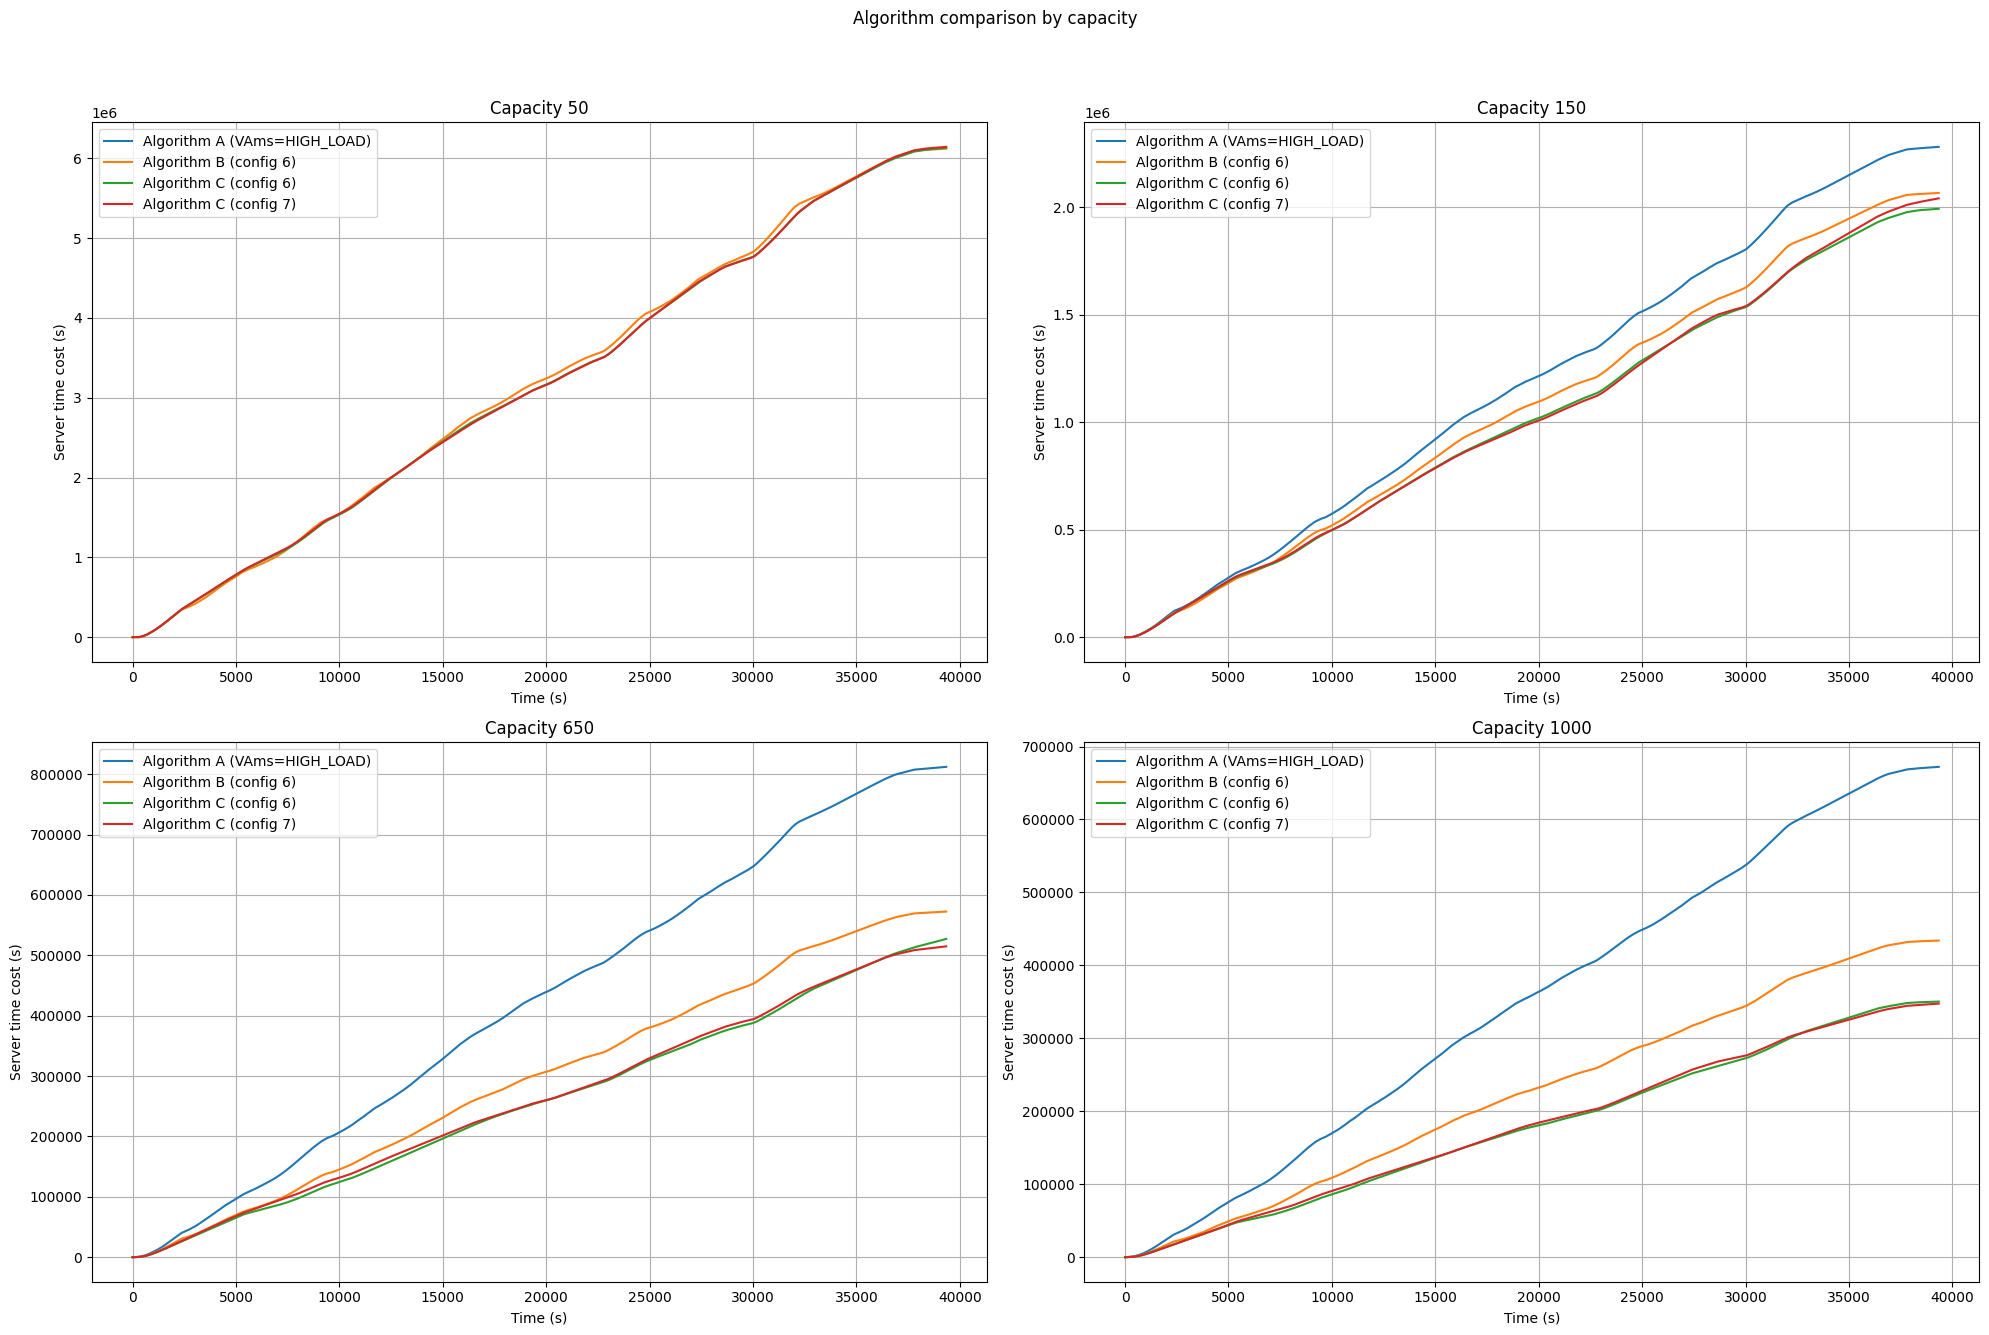

In [ ]:
def plot_instance(instance_capacity, instance_name, figtitle):
    timestamps = instance_progression[instance_capacity][instance_name]["timestamps"]
    viewer_count_array = instance_progression[instance_capacity][instance_name]["viewer_count_array"]
    timestamps_sessions = instance_progression[instance_capacity][instance_name]["timestamps_sessions"]
    sessions = instance_progression[instance_capacity][instance_name]["sessions"]
    instance = instance_progression[instance_capacity][instance_name]["instance"]
    fig, ax = plt.subplots(figsize=(15, 7))
    ax.plot(timestamps, viewer_count_array, 'b--', label="Total viewers")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Number of viewers")
    ax2 = ax.twinx()
    ax2.plot(instance["timestamp"], instance["server_platform_time_cost"], label="Total server time cost", color='black')
    ax2.set_ylabel("Server time cost (s)")
    ax3 = ax.twinx()
    ax3.plot(timestamps_sessions, sessions, 'r--', label="Total sessions")
    ax3.set_ylabel("Number of sessions")
    ax3.spines['right'].set_position(('outward', 60))
    ax4 = ax.twinx()
    ax4.plot(instance["timestamp"], instance["n_servers_current"], label="Servers currently in use", color='orange')
    ax4.set_ylabel("Number of servers (current)")
    ax4.spines['right'].set_position(('outward', 120))
    ax5 = ax.twinx()
    ax5.plot(instance["timestamp"], instance["n_servers_total"], label="Total servers used", color='purple')
    ax5.set_ylabel("Number of servers (total)")
    ax5.spines['right'].set_position(('outward', 180))
    ax6 = ax.twinx()
    ax6.plot(instance["timestamp"], instance["server_platform_avg_usage"], label="Avg server usage", color='green')
    ax6.set_ylabel("Server usage (% total capacity, 500 users max per server)")
    ax6.spines['right'].set_position(('outward', 240))
    ax6.set_ylim([0, 1])
    fig.legend(ncol=3)
    ax.grid()
    fig.suptitle(figtitle)

def plot_all():
    capacities = ["50", "150", "650", "1000"]
    fig, axs = plt.subplots(2, 2, figsize=(20, 14), sharex=False)
    axs = axs.flatten()
    for idx, instance_capacity in enumerate(capacities):
        ax = axs[idx]
        for instance_name in instance_progression[instance_capacity]:
            instance = instance_progression[instance_capacity][instance_name]["instance"]
            ax.plot(instance["timestamp"], instance["server_platform_time_cost"], label=instance_name)
        ax.set_xlabel("Time (s)")
        ax.set_ylabel("Server time cost (s)")
        ax.set_title(f"Capacity {instance_capacity}")
        ax.grid()
        ax.legend()
    fig.suptitle("Algorithm comparison by capacity")
plot_all()